## **Build Stateful Workflows using LangGraph**

### What is **LangGraph**?

LangGraph is a powerful framework designed to help developers build intelligent AI agents that can think, plan, and act on your behalf. At its core, LangGraph allows you to break down complex tasks into smaller, manageable steps, organize these steps logically, and connect them like a roadmap using something called **graphs**. These graphs visually represent the flow of tasks, making it easy to see how each step is connected and in what order they should be executed.  

Think of LangGraph as a toolkit for creating smart assistants. These assistants don’t just follow instructions—they understand what you want, figure out the best way to achieve it, and carry out the tasks automatically. By using LangGraph, you can design AI systems that are structured, adaptable, and capable of handling everything from simple workflows to complicated problem-solving tasks.


### Why **LangGraph**?  

LangGraph offers unique advantages for building intelligent AI agents, especially when compared to frameworks such as LangChain. One of its standout features is the ability to create **cyclic graphs** in addition to Directed Acyclic Graphs (DAGs). Here's why that matters:  

1. **Support for Cyclic Graphs:**  
   Although tools such as LangChain are limited to DAGs—where tasks must follow a strict, linear flow without loops—LangGraph allows for **cyclic graphs**, where tasks can revisit earlier steps. This is crucial for workflows that require iterative processes, feedback loops, or retries.

   For example:  
   - An AI agent analyzing customer feedback might revisit earlier steps to refine its understanding based on new data.  
   - A process for refining a document might loop through draft, review, and revise steps multiple times.

3. **Enhanced Workflow Flexibility:**  
   Cyclic graphs make LangGraph ideal for real-world scenarios where tasks don’t always follow a one-way path. It can handle dynamic workflows where agents need to adapt, reevaluate, or repeat steps as needed, providing greater flexibility.  

4. **Powerful Iterative Processes:**  
   By enabling loops, LangGraph supports processes such as optimization, data refinement, or real-time adjustments, ensuring the AI agent delivers more accurate and meaningful results.  

5. **All-in-One Solution:**  
   LangGraph doesn’t just manage tasks but also integrates the benefits of both DAGs (for structured flows) and cyclic graphs (for iterative workflows). This makes it a more versatile framework for designing intelligent, adaptable AI agents.  

With LangGraph, you’re not constrained by one-way task flows. Its support for cyclic graphs allows you to model more complex, real-world problems with ease, making it a go-to choice for AI development.  


## Components of LangGraph  

LangGraph’s strength lies in its structured and intuitive design, composed of essential building blocks that enable the creation of intelligent AI agents, with default stages denoting start and end of workflow.


There are main three components:

1. Nodes: Which represents functions or individual steps that do the actual computational.

2. Edges: Define how the execution flow from one step to another (one node to another).

3. State: Remember everything across all the nodes. keep the workflow's context alive. 

In this example, we are defining a state structure for a **user authentication workflow**. The state, called `AuthState`, is a typed dictionary that holds information about a user's credentials (username and password) and their authentication status (`is_authenticated`) as shown here: 


In this example, we are defining a state structure for a **user authentication workflow**. The state, called `AuthState`, is a typed dictionary that holds information about a user's credentials (username and password) and their authentication status (`is_authenticated`) as shown here: 

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/dhl478pwbZzrxzmcjJY4xw/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM.png" alt="Screenshot" width="300">
</div>



### **1. States**  
States represent the **current condition or context** within a workflow. They store and manage information as the agent progresses from one node to the next. 

For instance:  
- A state might capture user input, store the results of a database query, or reflect the status of an ongoing process.  

States ensure the AI agent has access to relevant information at the right time, enabling dynamic and context-aware behavior.

#### Example: Class Description - `AuthState`  
Using `from typing import TypedDict, Optional`, the `AuthState` class is defined as a `TypedDict` that specifies the structure of a dictionary representing a user's authentication state. Each key has a specific type, and all fields are optional (`Optional`), meaning they can either hold a value of the specified type or be `None`.

#### State Keys and Types:
- **`username`**: `Optional[str]` - The user's username; it can be a string or `None`.
- **`password`**: `Optional[str]` - The user's password; it can be a string or `None`.
- **`is_authenticated`**: `Optional[bool]` - Indicates whether the user is authenticated; it can be a boolean or `None`.
- **`output`**: `Optional[str]` - A message or result related to authentication; it can be a string or `None`.

This structure ensures that the authentication state is consistently defined and type-safe, while also accommodating scenarios where some fields may be unavailable or unused.


In [2]:
from typing import TypedDict,Optional

In [3]:
class AuthState(TypedDict):
    
    username:Optional[str]
    password:Optional[str]
    is_authenticated:Optional[bool]
    output:Optional[str]

In [5]:
auth_state_1:AuthState = {
    "username":"seran123",
    "password":"12345",
    "is_authenticated":True,
    "output":"Login successful"
}

print("auth_state_1:", auth_state_1)

auth_state_1: {'username': 'seran123', 'password': '12345', 'is_authenticated': True, 'output': 'Login successful'}


In [6]:
auth_state_2:AuthState = {
    "username": "",
    "password":"wrong",
    "is_authenticated":False,
    "output": "Login failed"
}

print("auth_state_2: ", auth_state_2)

auth_state_2:  {'username': '', 'password': 'wrong', 'is_authenticated': False, 'output': 'Login failed'}


This state serves as the backbone for workflows involving user authentication. It will be passed between nodes in a graph to validate the credentials and update the `is_authenticated` field accordingly.


### **2. Nodes**  
Nodes are the **core units of action** in LangGraph. Each node represents a specific task or operation that the AI agent needs to perform. 

For example:  
- A node could fetch data from an API, process information, or generate a response.  

Nodes can vary in complexity, from simple calculations to executing intricate workflows, and they form the foundation of any graph in LangGraph.  


#### Defining the Input Node

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QPsWYzaKkacLUn8V1SbyWA/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh.png" alt="Screenshot" width="300">
</div>


Now we define the `input_node`, which collects the user's username and password if they are not already provided in the state. This node ensures that the state is populated with the necessary input for authentication.

This node is usually the starting point in the graph, ensuring that the required input data is gathered before proceeding to the authentication step.


In [10]:
def input_node(state:AuthState):
    
    print(state)
    
    if state.get("username","") == "":
        username = input("Please enter the username here")
        
    password = input("Enter your password")
    
    if state.get("username","") == "":
        return{
            "username":username,
            "password": password
        }
        
    return{
        "password": password
    }

In [12]:
input_node(auth_state_1)

{'username': 'seran123', 'password': '12345', 'is_authenticated': True, 'output': 'Login successful'}


{'password': 'hi123'}

In [13]:
input_node(auth_state_2)

{'username': '', 'password': 'wrong', 'is_authenticated': False, 'output': 'Login failed'}


{'username': 'vishwa', 'password': '1234'}

### Defining the Validate Credentials Node  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/OI9x1j0MXYtlsjdGGPemqA/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-1-.png" alt="Screenshot" width="300">
</div>


The node is a fundamental building block of a graph that encapsulates a unit of computation or functionality. It represents a single step in a workflow or process, typically taking input, performing an action, and providing output. Each node is connected to others to define the flow of logic or data.

For your example, the ```validate_credentials_node``` would function as a node in Langraph, performing the task of validating user credentials. 

The `validate_credentials_node` takes the current state as input and is responsible for checking the user's credentials (username and password) provided in the state. Based on the validation, it updates the state with an `is_authenticated` value, indicating whether the authentication was successful or not. This node ensures that the validation result is added to the state, allowing the graph to determine the next step in the workflow based on whether the authentication was successful.


In [14]:
def validate_node(state:AuthState):
    
    username = state.get("username","")
    password = state.get("password","")
    
    print("username: "+ username + "\nPassword: "+ password)
    
    if username == "test_user" and password == "correctpass":
        is_authenticated = True
    
    else:
        is_authenticated = False
        
    return{
        "is_authenticated": is_authenticated
    }

In [15]:
validate_node(auth_state_1)

username: seran123
Password: 12345


{'is_authenticated': False}

In [16]:
auth_state_3:AuthState = {
    "username":"test_user",
    "password":"correctpass",
    "is_authenticated":False,
    "output": "Authentication failed. Please try again."
}

print(f"auth_state_3: {auth_state_3}")

auth_state_3: {'username': 'test_user', 'password': 'correctpass', 'is_authenticated': False, 'output': 'Authentication failed. Please try again.'}


In [17]:
validate_node(auth_state_3)

username: test_user
Password: correctpass


{'is_authenticated': True}

#### Defining the Success Node  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/PwwDttqbSAwfrYvOQP2X-A/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-2-.png" alt="Screenshot" width="300">
</div>


The `success_node` takes the current state as input and is triggered when the authentication process is successful. It returns a success message to indicate that the user has been authenticated.


In [18]:
def success_node(state:AuthState):
    
    return{
        "output": "Authentication Successful. Welcome!!!"
    }

In [19]:
success_node(auth_state_3)

{'output': 'Authentication Successful. Welcome!!!'}

#### Defining the Failure Node 

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/69hJU9b_hk_UNARWJW6IEw/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-3-.png" alt="Screenshot" width="300">
</div>


The `failure_node` takes the current state as input and is triggered when the authentication process fails. It returns an output indicating the failure to authenticate.



In [20]:
def failure_node(state:AuthState):
    
    return{
        "output": "Authentication failed, please try again!"
    }

In [21]:
failure_node(auth_state_2)

{'output': 'Authentication failed, please try again!'}

#### Defining the Router Node  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/FpW7oG5oTxIPsaOqpxT7ow/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-4-.png" alt="Screenshot" width="300">
</div>


The `router` node acts as a decision-making point in the workflow. It takes the current state as input and determines the next node to execute based on the `is_authenticated` value in the state.


In [33]:
def router(state:AuthState):
    
    if state['is_authenticated']:
        return "success_node"
    
    else:
        return "failure_node"

This node ensures that the graph transitions to the appropriate node—either the success or failure node—based on whether the authentication was successful. It is an essential part of managing conditional logic in the workflow.


#### Creating the Graph  

To begin building the workflow, we need to create a graph that will serve as the foundation for connecting nodes and defining the application's logic. We create a new instance of `StateGraph` using our `AuthState` structure, which acts as a blueprint for the application's state. This graph will manage the flow of execution between nodes, ensuring a seamless and organized workflow.


In [24]:
from langgraph.graph import StateGraph, END

In [25]:
workflow = StateGraph(AuthState)
workflow

#### Adding Nodes to the Graph  

Now, we add nodes to the graph to define the tasks and logic of the workflow. Nodes are added using the `add_node` method, which takes two arguments:  

1. **Node Name**: A unique string identifier for the node.  
2. **Node Function**: The function that will execute the logic for this node.  


To gather user input for authentication, we add the `input_node` to the graph using the `add_node` method. This node prompts the user to enter their username and password if they are not already present in the state.

- `"InputNode"`: This is the unique identifier for the input node.  
- `input_node`: The function that collects the username and password from the user and updates the state accordingly.  



In [26]:
workflow.add_node("InputNode", input_node)

In [27]:
workflow.add_node("ValidateNode", validate_node)

In [28]:
workflow.add_node("SuccessNode", success_node)

In [29]:
workflow.add_node("FailureNode", failure_node)

### **3. Edges**  

Edges define the **connections between nodes** and represent the flow of execution within the graph. They dictate how the AI agent transitions from one task to another based on predefined logic or conditions. In the authentication workflow, edges guide the application flow, determining the path taken based on the results of each node's execution.

#### **Authentication Use Case Example**  
- **Input Node**: The edge flows from this node to the **Validate Credentials Node**, where the user input (username and password) is validated.  
- **Failure Node**: If authentication fails, the flow moves back to the **Input Node** to prompt the user to re-enter their credentials.
- **Success Node**: If authentication succeeds, the flow ends after providing a success message, indicating the successful completion of the authentication process.


#### Adding the Edge Between InputNode and ValidateCredential Node  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/2M4XoL8bc2Em8o_0T9XQbg/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-5-.png" alt="Screenshot" width="300">
</div>


To establish the connection between the `InputNode` and the `ValidateCredential` node, we use the `add_edge` method. This edge represents the flow from the user input phase to the credential validation phase, ensuring that once the user enters their details, the next step is to validate them.



In [30]:
workflow.add_edge("InputNode","ValidateNode")

In [31]:
workflow.add_edge("FailureNode", "InputNode")

In [32]:
workflow.add_edge("SuccessNode", END)

### **Conditional Edges**  

Conditional edges enable **decision-making** by allowing transitions between nodes based on specific conditions within the state. These edges define the flow of execution based on outcomes such as user input, validation results, or any other predefined logic. By using conditional edges, the AI agent can dynamically choose its path based on the results of previous tasks.  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/dcXTJEOQ8nhYh7AvVdW9Mw/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-8-.png" alt="Screenshot" width="300">
</div>


### **Building an Authentication Workflow**

#### **Authentication Use Case Example**  
In our authentication flow, we can introduce conditional edges that determine whether the user successfully authenticated or not. These edges are used to decide the next step based on the authentication result.

- **Validate Credentials Node**: After validating the user credentials, the system uses a conditional edge to decide:
  - If `is_authenticated` is `True`, the flow moves to the **Success Node**.
  - If `is_authenticated` is `False`, the flow loops back to the **InputNode** so the user can try entering their credentials again.


**`add_conditional_edges(start, router, conditions)`**: This method defines the conditional transitions from a given node.
  - **`start`**: The node where the conditional edges start (in this case, `"ValidateCredential"`).
  - **`router`**: A function that determines the condition. It checks the current state (like the `is_authenticated` status) and returns the appropriate node to transition to (either `"Success"` or `"Failure"`).
  - **`conditions`**: A dictionary that maps conditions (such as `"success_node"` or `"failure_node"`) to target nodes, indicating where to direct the flow based on the condition.


In [34]:
workflow.add_conditional_edges("ValidateNode", router, {
    "success_node": "SuccessNode",
    "failure_node": "FailureNode"
})

#### Setting the Entry Point  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/rxNr7amJUiaEyhZKYc-JFg/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-9-.png" alt="Screenshot" width="300">
</div>


The **entry point** defines where the workflow starts. By setting an entry point, you're specifying the first node that the AI agent will execute when the workflow begins. In our authentication use case, we want the workflow to start at the **InputNode**, where the user will be prompted to enter their credentials.

By defining the entry point, we ensure the workflow initiates at the input phase, guiding the user through the authentication process step by step.


In [35]:
workflow.set_entry_point("InputNode")

#### Compiling the Workflow  

Once all the nodes and edges are defined in the workflow, the next step is to compile it. Compiling the workflow transforms the defined nodes, edges, and logic into a ready-to-use application that can execute the defined tasks sequentially or conditionally, as per the graph's structure.



#### Running the Application  

Once the workflow is compiled, we can run it by invoking the application with the required inputs. The `invoke` method takes an initial state (a dictionary of input values) and starts execution from the entry point defined in the workflow.

<p style='color: red'><b>Note:</b> The correct password is <code>secure_password</code>, so make sure to enter that to authenticate successfully.</p>


In [37]:
app = workflow.compile()

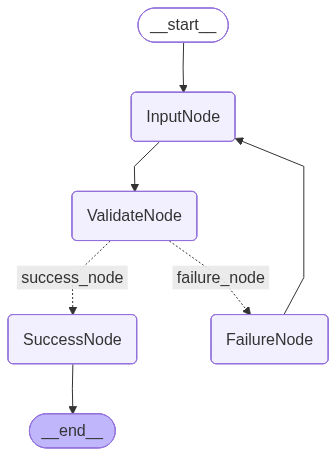

In [38]:
app

In [42]:
inputs = {
    "username": ""
}

In [43]:
app.invoke(inputs)

{'username': ''}
username: test_user
Password: correctpass


{'username': 'test_user',
 'password': 'correctpass',
 'is_authenticated': True,
 'output': 'Authentication Successful. Welcome!!!'}